# SmartImageSearch
Content-Based Image Retrieval System

This notebook implements two retrieval pipelines for image search:
1. Classical pipeline based on handcrafted visual features
2. Modern pipeline based on deep visual embeddings

Dataset: CIFAR-10 subset

# Import

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import datasets, transforms, models

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Configurazione

In [2]:
# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Retrieval parameters
TOP_K = 5
NUM_IMAGES_PER_CLASS = 100

# CIFAR-10 class names
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Selected classes for the project
SELECTED_CLASSES = ['airplane', 'automobile', 'cat', 'dog']
SELECTED_CLASS_IDS = [CLASS_NAMES.index(c) for c in SELECTED_CLASSES]

print("Selected classes:", SELECTED_CLASSES)

Using device: cuda
Selected classes: ['airplane', 'automobile', 'cat', 'dog']


# Trasformazioni e caricamento dataset

In [3]:
train_dataset = datasets.CIFAR10(root="./data", train=True, download=True)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 170M/170M [00:03<00:00, 49.0MB/s]


Train size: 50000
Test size: 10000


# Creazione subset

In [4]:
def build_subset(dataset, selected_class_ids, num_images_per_class=100):
    subset_images = []
    subset_labels = []
    counters = {class_id: 0 for class_id in selected_class_ids}

    for img, label in dataset:
        if label in selected_class_ids and counters[label] < num_images_per_class:
            subset_images.append(img)
            subset_labels.append(label)
            counters[label] += 1

        if all(counters[c] >= num_images_per_class for c in selected_class_ids):
            break

    return subset_images, subset_labels

images, labels = build_subset(
    test_dataset,
    selected_class_ids=SELECTED_CLASS_IDS,
    num_images_per_class=NUM_IMAGES_PER_CLASS
)

print("Subset size:", len(images))
for class_id in SELECTED_CLASS_IDS:
    print(CLASS_NAMES[class_id], labels.count(class_id))

Subset size: 400
airplane 100
automobile 100
cat 100
dog 100


# Visualizzazione esempi

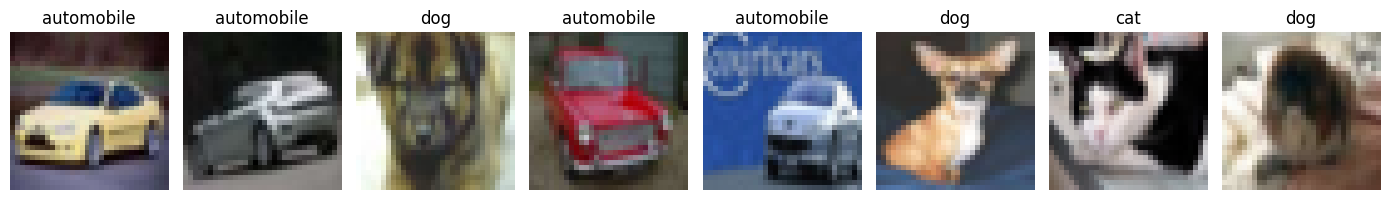

In [5]:
def show_sample_images(images, labels, class_names, n=8):
    plt.figure(figsize=(14, 4))
    indices = random.sample(range(len(images)), n)

    for i, idx in enumerate(indices):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[idx])
        plt.title(class_names[labels[idx]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_images(images, labels, CLASS_NAMES, n=8)

# PIPELINE CLASSICA

## Feature classiche: color histogram

In [6]:
def extract_color_histogram(image, bins_per_channel=16):
    """
    Extract a normalized RGB color histogram from a PIL image.
    Returns a 1D feature vector.
    """
    img_np = np.array(image)

    hist_r, _ = np.histogram(img_np[:, :, 0], bins=bins_per_channel, range=(0, 256))
    hist_g, _ = np.histogram(img_np[:, :, 1], bins=bins_per_channel, range=(0, 256))
    hist_b, _ = np.histogram(img_np[:, :, 2], bins=bins_per_channel, range=(0, 256))

    feature = np.concatenate([hist_r, hist_g, hist_b]).astype(np.float32)

    # L1 normalization
    feature /= (feature.sum() + 1e-8)

    # L2 normalization
    feature /= (np.linalg.norm(feature) + 1e-8)

    return feature

## Costruzione feature database classico

In [7]:
classic_features = np.array([extract_color_histogram(img) for img in images])
print("Classical feature shape:", classic_features.shape)

Classical feature shape: (400, 48)


## Distanza euclidea e retrieval classico

In [8]:
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

def retrieve_classic(query_index, features, top_k=5):
    query_feature = features[query_index]
    distances = []

    for i in range(len(features)):
        d = euclidean_distance(query_feature, features[i])
        distances.append((i, d))

    distances = sorted(distances, key=lambda x: x[1])
    return distances[:top_k + 1]  # includes query image

## Visualizzazione risultati classici

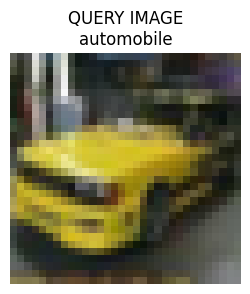

Query label: automobile


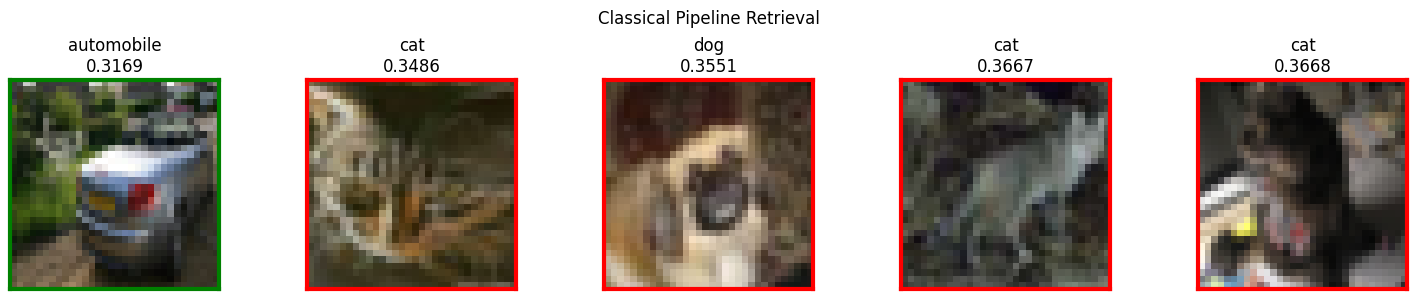

In [9]:
def show_query_image(query_index, images, labels, class_names):
    plt.figure(figsize=(3, 3))
    plt.imshow(images[query_index])
    plt.title(f"QUERY IMAGE\n{class_names[labels[query_index]]}")
    plt.axis("off")
    plt.show()


def show_retrieval_results(results, images, labels, class_names, query_label, title="Retrieval Results"):
    plt.figure(figsize=(15, 3))

    for i, (idx, score) in enumerate(results):
        plt.subplot(1, len(results), i + 1)
        plt.imshow(images[idx])

        predicted_label = class_names[labels[idx]]
        is_relevant = labels[idx] == query_label

        plt.title(f"{predicted_label}\n{score:.4f}")

        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_edgecolor("green" if is_relevant else "red")

        plt.xticks([])
        plt.yticks([])

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()



query_index = random.randint(0, len(images) - 1)
query_label = labels[query_index]

show_query_image(query_index, images, labels, CLASS_NAMES)

classic_results = retrieve_classic(query_index, classic_features, top_k=TOP_K)
print("Query label:", CLASS_NAMES[query_label])

show_retrieval_results(
    classic_results[1:],  # exclude query itself in display
    images,
    labels,
    CLASS_NAMES,
    query_label=query_label,
    title="Classical Pipeline Retrieval"
)

# PIPELINE 2

## Trasformazioni per ResNet

In [10]:
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Modello pre-trained

In [11]:
weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=weights)

# Remove classification head
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
feature_extractor.to(device)
feature_extractor.eval()

print("Pretrained ResNet18 feature extractor loaded.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 115MB/s]


Pretrained ResNet18 feature extractor loaded.


## Funzione di estrazione embedding

In [12]:
def extract_deep_embedding(image, model, transform, device):
    x = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model(x)

    embedding = embedding.squeeze().cpu().numpy().astype(np.float32)
    return embedding

## Costruzione feature database moderno

In [13]:
deep_features = []

for img in images:
    emb = extract_deep_embedding(img, feature_extractor, resnet_transform, device)
    deep_features.append(emb)

deep_features = np.array(deep_features)

# Normalize embeddings for cosine similarity
deep_features = normalize(deep_features)

print("Deep feature shape:", deep_features.shape)

Deep feature shape: (400, 512)


## Retrieval moderno con cosine similarity

In [14]:
def retrieve_deep(query_index, features, top_k=5):
    query_feature = features[query_index].reshape(1, -1)
    sims = cosine_similarity(query_feature, features)[0]

    results = list(enumerate(sims))
    results = sorted(results, key=lambda x: x[1], reverse=True)
    return results[:top_k + 1]  # includes query image

##Visualizzazione risultati moderni

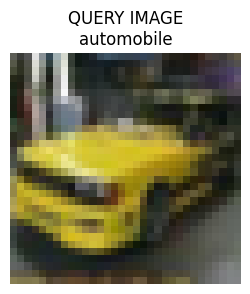

Query label: automobile


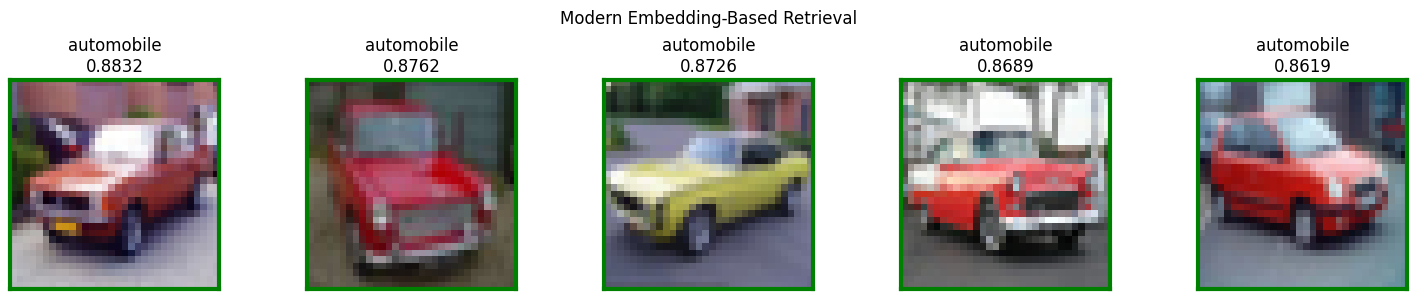

In [15]:
show_query_image(query_index, images, labels, CLASS_NAMES)

deep_results = retrieve_deep(query_index, deep_features, top_k=TOP_K)
print("Query label:", CLASS_NAMES[query_label])

show_retrieval_results(
    deep_results[1:],  # exclude query itself in display
    images,
    labels,
    CLASS_NAMES,
    query_label=query_label,
    title="Modern Embedding-Based Retrieval"
)

##Confronto diretto sulla stessa query

Same query used for both pipelines:


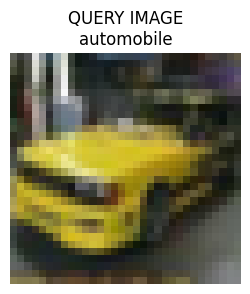

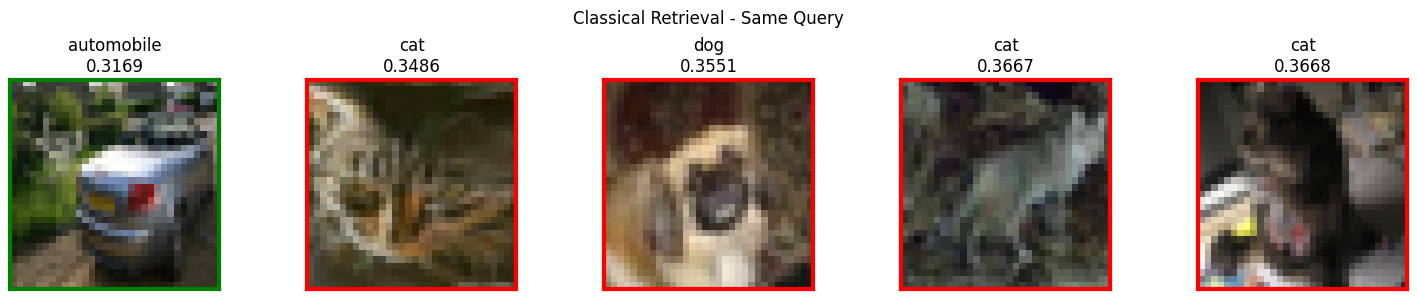

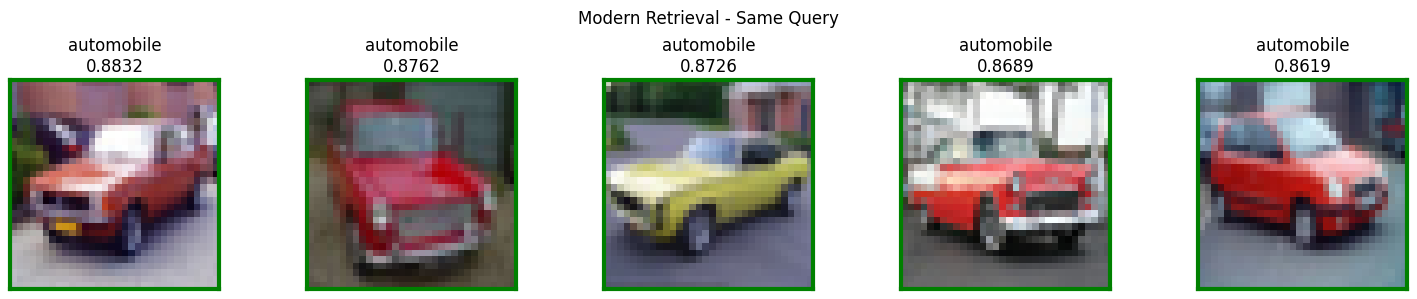

In [16]:
print("Same query used for both pipelines:")
show_query_image(query_index, images, labels, CLASS_NAMES)

classic_results = retrieve_classic(query_index, classic_features, top_k=TOP_K)
deep_results = retrieve_deep(query_index, deep_features, top_k=TOP_K)

show_retrieval_results(
    classic_results[1:],
    images,
    labels,
    CLASS_NAMES,
    query_label=query_label,
    title="Classical Retrieval - Same Query"
)

show_retrieval_results(
    deep_results[1:],
    images,
    labels,
    CLASS_NAMES,
    query_label=query_label,
    title="Modern Retrieval - Same Query"
)

##Precision@K

In [17]:
def precision_at_k(results, query_label, labels, k=5, skip_first=True):
    selected = results[1:k+1] if skip_first else results[:k]
    relevant = sum(1 for idx, _ in selected if labels[idx] == query_label)
    return relevant / k

def precision_at_1(results, query_label, labels, skip_first=True):
    selected = results[1] if skip_first else results[0]
    idx = selected[0]
    return 1 if labels[idx] == query_label else 0


def evaluate_pipeline(features, retrieval_fn, labels, k=5):
    p_at_1_scores = []
    p_at_k_scores = []

    for query_index in range(len(labels)):
        results = retrieval_fn(query_index, features, top_k=k)
        query_label = labels[query_index]

        p1 = precision_at_1(results, query_label, labels, skip_first=True)
        pk = precision_at_k(results, query_label, labels, k=k, skip_first=True)

        p_at_1_scores.append(p1)
        p_at_k_scores.append(pk)

    return np.mean(p_at_1_scores), np.mean(p_at_k_scores)

classic_p_at_1, classic_p_at_5 = evaluate_pipeline(classic_features, retrieve_classic, labels, k=5)
deep_p_at_1, deep_p_at_5 = evaluate_pipeline(deep_features, retrieve_deep, labels, k=5)

print("Classical Pipeline")
print(f"Precision@1: {classic_p_at_1:.4f}")
print(f"Precision@5: {classic_p_at_5:.4f}")

print("\nModern Pipeline")
print(f"Precision@1: {deep_p_at_1:.4f}")
print(f"Precision@5: {deep_p_at_5:.4f}")

Classical Pipeline
Precision@1: 0.4150
Precision@5: 0.3485

Modern Pipeline
Precision@1: 0.8225
Precision@5: 0.7890


##Grafico confronto finale

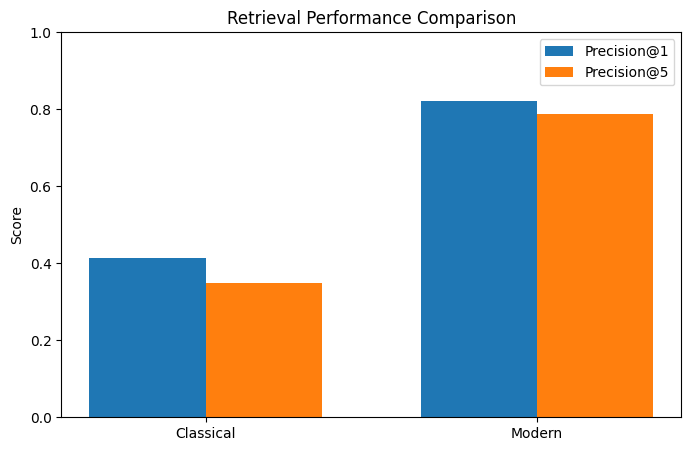

In [18]:
methods = ["Classical", "Modern"]
p1_scores = [classic_p_at_1, deep_p_at_1]
p5_scores = [classic_p_at_5, deep_p_at_5]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, p1_scores, width, label="Precision@1")
plt.bar(x + width/2, p5_scores, width, label="Precision@5")

plt.xticks(x, methods)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Retrieval Performance Comparison")
plt.legend()
plt.show()

###FINAL TEXTUAL SUMMARY

In [19]:
print("Classical vs Modern Summary:")
print(f"Classical Precision@1: {classic_p_at_1:.4f}")
print(f"Classical Precision@5: {classic_p_at_5:.4f}")
print(f"Modern Precision@1:    {deep_p_at_1:.4f}")
print(f"Modern Precision@5:    {deep_p_at_5:.4f}")

Classical vs Modern Summary:
Classical Precision@1: 0.4150
Classical Precision@5: 0.3485
Modern Precision@1:    0.8225
Modern Precision@5:    0.7890


## Conclusions

- The classical pipeline uses handcrafted visual descriptors such as color histograms.
- The modern pipeline uses deep embeddings extracted from a pre-trained ResNet18.
- The modern approach is expected to provide semantically richer retrieval results.
- This notebook implements the practical evolution described in the SmartImageSearch project.

#Demo CBIR

Insert image index (0-399): 42
Selected image index: 42
Category: airplane


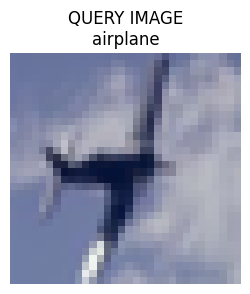

In [24]:
# ==========================================
# QUERY IMAGE SELECTION
# ==========================================

QUERY_IMAGE = int(input(f"Insert image index (0-{len(images)-1}): "))

query_index = QUERY_IMAGE
query_label = labels[query_index]

print("Selected image index:", query_index)
print("Category:", CLASS_NAMES[query_label])

show_query_image(
    query_index,
    images,
    labels,
    CLASS_NAMES
)

CLASSICAL RETRIEVAL
-------------------


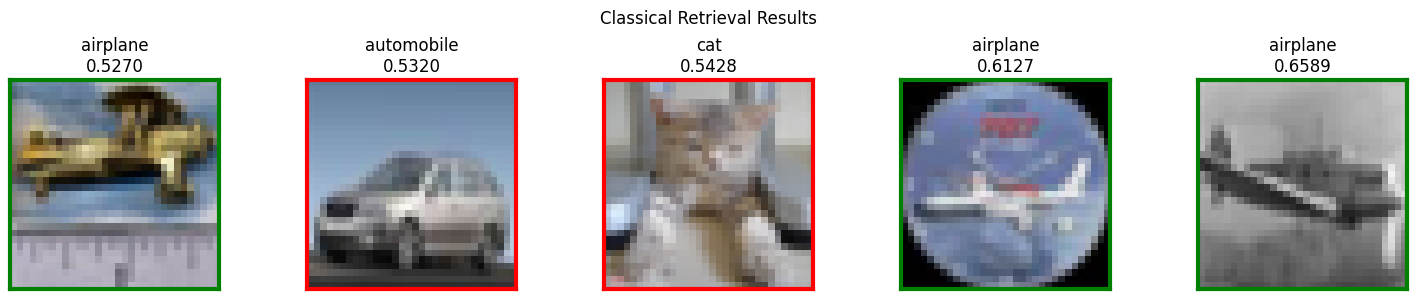

In [25]:
# ==========================================
# CLASSICAL PIPELINE DEMO
# ==========================================

classic_results = retrieve_classic(
    query_index,
    classic_features,
    top_k=TOP_K
)

print("CLASSICAL RETRIEVAL")
print("-------------------")

show_retrieval_results(
    classic_results[1:],  # remove query image
    images,
    labels,
    CLASS_NAMES,
    query_label=query_label,
    title="Classical Retrieval Results"
)

MODERN RETRIEVAL
----------------


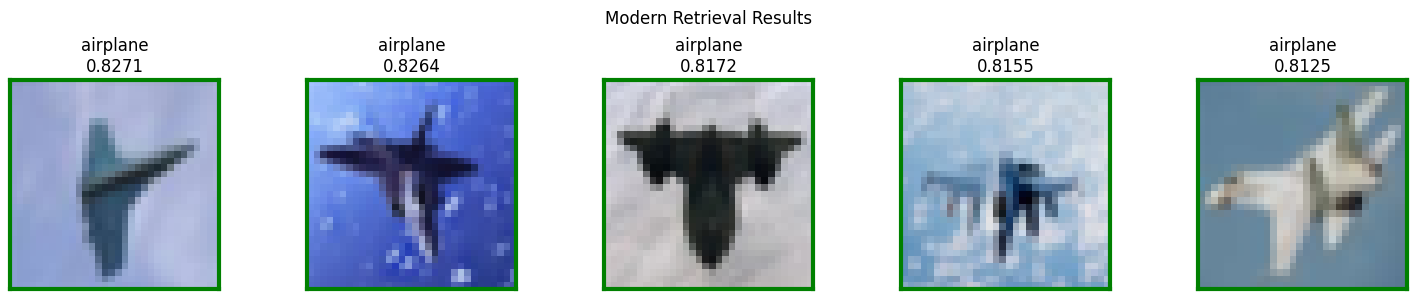

In [26]:
# ==========================================
# MODERN PIPELINE DEMO
# ==========================================

deep_results = retrieve_deep(
    query_index,
    deep_features,
    top_k=TOP_K
)

print("MODERN RETRIEVAL")
print("----------------")

show_retrieval_results(
    deep_results[1:],  # remove query image
    images,
    labels,
    CLASS_NAMES,
    query_label=query_label,
    title="Modern Retrieval Results"
)

Query Category: airplane


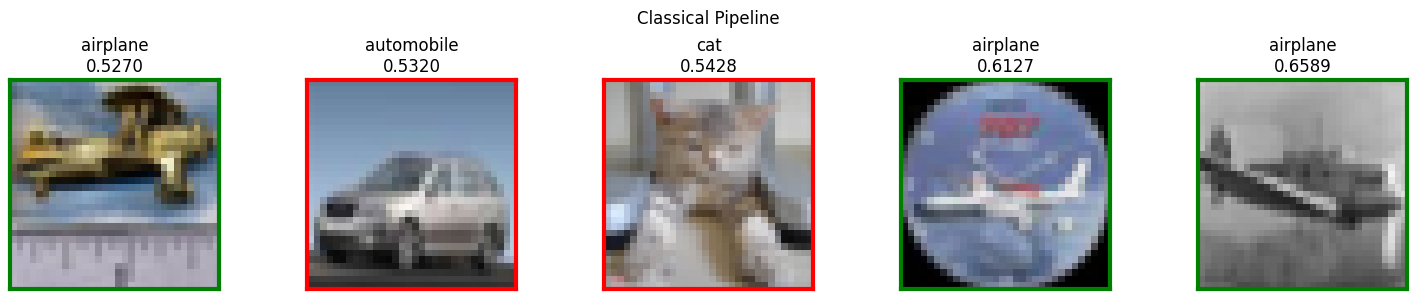

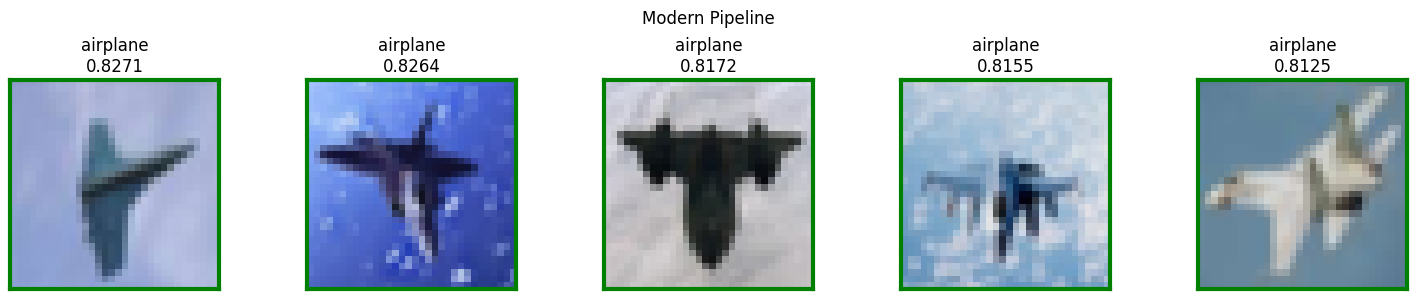

In [27]:
# ==========================================
# SIDE-BY-SIDE COMPARISON
# ==========================================

print("Query Category:", CLASS_NAMES[query_label])

show_retrieval_results(
    classic_results[1:],
    images,
    labels,
    CLASS_NAMES,
    query_label=query_label,
    title="Classical Pipeline"
)

show_retrieval_results(
    deep_results[1:],
    images,
    labels,
    CLASS_NAMES,
    query_label=query_label,
    title="Modern Pipeline"
)

#Demo Retrieval Testuale

##Funzione di ricerca testuale

In [21]:
def text_search(query_class, labels, class_names):
    """
    Simple text-based image retrieval using image labels.

    Parameters:
        query_class (str): class name to search
        labels (list): image labels
        class_names (list): CIFAR-10 class names

    Returns:
        list: indices of matching images
    """

    query_class = query_class.lower()

    if query_class not in class_names:
        print(f"Class '{query_class}' not found.")
        print("Available classes:")
        print(class_names)
        return []

    class_id = class_names.index(query_class)

    results = []

    for i, label in enumerate(labels):
        if label == class_id:
            results.append(i)

    return results

##Visualizzazione dei primi risultati

In [22]:
def show_text_search_results(results, images, labels, class_names, max_results=5):

    if len(results) == 0:
        print("No results found.")
        return

    n = min(max_results, len(results))

    plt.figure(figsize=(15, 3))

    for i in range(n):
        idx = results[i]

        plt.subplot(1, n, i + 1)
        plt.imshow(images[idx])
        plt.title(class_names[labels[idx]])
        plt.axis("off")

    plt.suptitle("Text-Based Retrieval Results")
    plt.tight_layout()
    plt.show()

Insert a category (e.g. airplane, automobile, cat, dog): dog

Found 100 matching images.


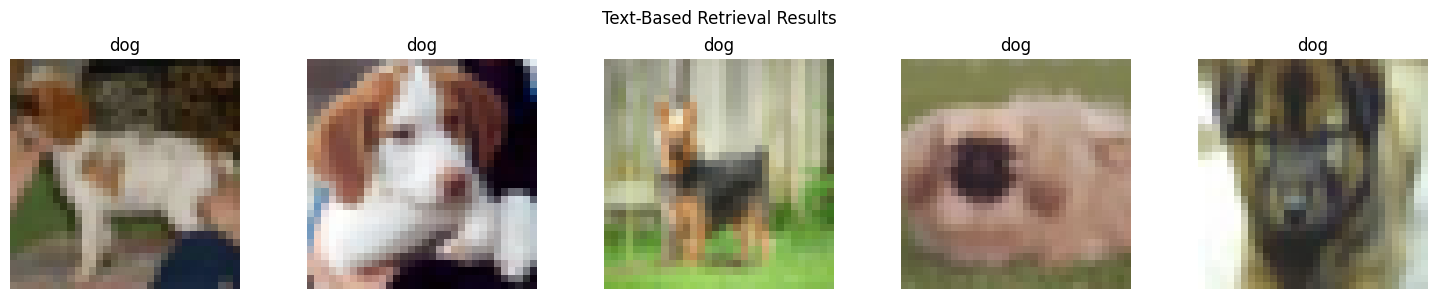

In [23]:
query_text = input("Insert a category (e.g. airplane, automobile, cat, dog): ").lower()

results = text_search(
    query_text,
    labels,
    CLASS_NAMES
)

print(f"\nFound {len(results)} matching images.")

show_text_search_results(
    results,
    images,
    labels,
    CLASS_NAMES,
    max_results=5
)